In [15]:
import numpy as np
from concurrent.futures import ProcessPoolExecutor
from tqdm import tqdm
import pandas as pd
from utils import *
import pandas as pd
import os
new_data = np.linspace(0, 1, 1000) 
seed = 42
args = {"max_leaf_nodes": 5}


Simulations: 100%|██████████| 2000/2000 [59:40<00:00,  1.79s/simulation] 


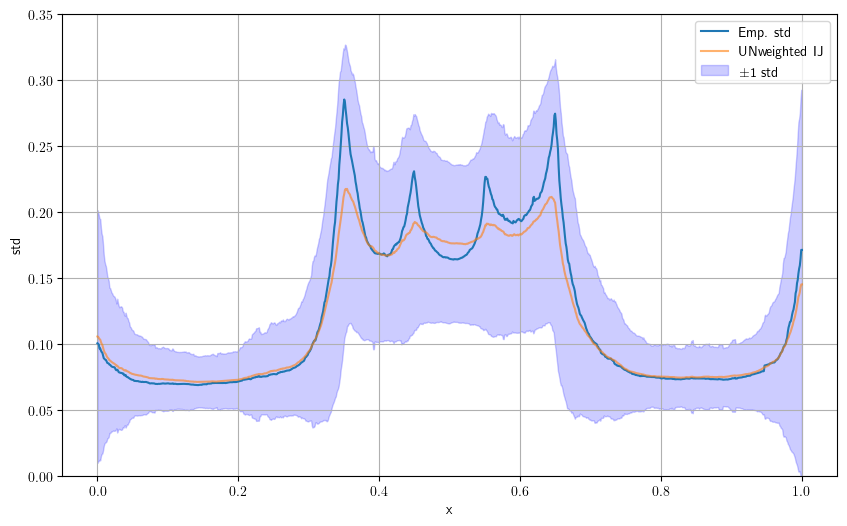

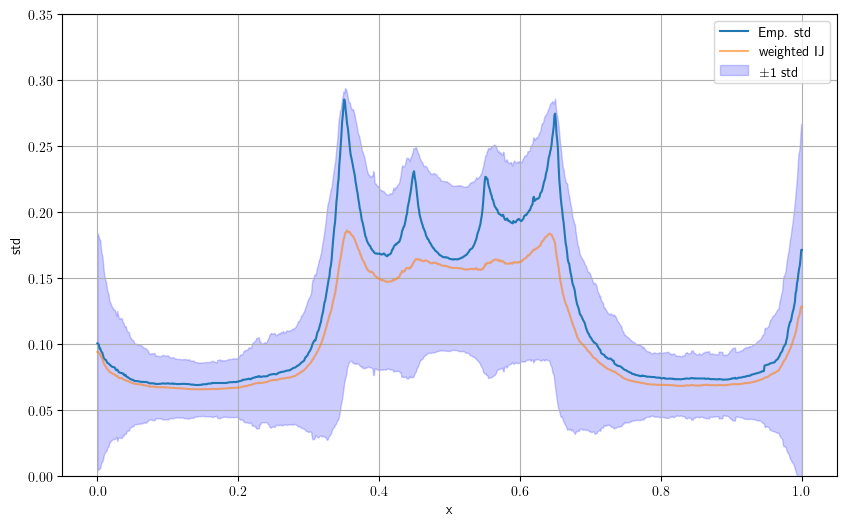

0


In [16]:
####### Simulation parameters  
n_sim = 2000
n = 500
B = 10_000                                                #  <--------- number of bootstrap samples
folder_name = f"n500_B10_000_non_uniform_weights"     # <--------- folder name for results

weighted_boot_samples = True


#######  run sim and save results
n_pred = new_data.shape[0]
#sim description 
text = f"n={n}, B={B}, seed={seed}, max_leaf_nodes={args['max_leaf_nodes']}, n_pred={n_pred} und {n_sim} Simulationen."

def make_folder(text,folder_name):
    folder_name2 = folder_name
    if not os.path.exists("./results/" + folder_name2):
        os.makedirs("./results/" + folder_name2)
    with open("./results/" + folder_name2 + "/readme.txt", "w") as f:
        f.write(text)
        
make_folder(text,folder_name)


# run sim and save results
with ProcessPoolExecutor() as executor:
    
    bagged_preds = np.zeros((n_sim, new_data.shape[0]))
    biased_var_estimates = np.zeros((n_sim, new_data.shape[0]))
    bias_corrections = np.zeros((n_sim, new_data.shape[0]))
    biased_var_estimates_w = np.zeros((n_sim, new_data.shape[0]))
    bias_corrections_w = np.zeros((n_sim, new_data.shape[0]))
    
    futures = [
        executor.submit(
            simulate_bagging_and_variance,
                n = n,
                B = B,
                new_data = new_data,
                simulation_index = i,
                seed = seed,
                dt_args = args,
                weighted_boot_samples = weighted_boot_samples,            # <--------- ungewichtete boot-samples erzeugen = None
        )
        for i in range(n_sim)
    ]

    for i, future in enumerate(tqdm(futures, desc="Simulations", unit="simulation")):
        bagged_prediction, biased_var_estimate, bias_correction, biased_var_estimate_w, bias_correction_w = future.result()
        bagged_preds[i, :] = bagged_prediction
        biased_var_estimates[i, :] = biased_var_estimate
        bias_corrections[i, :] = bias_correction
        biased_var_estimates_w[i, :] = biased_var_estimate_w
        bias_corrections_w[i, :] = bias_correction_w

# save results
np.save(f"./results/{folder_name}/bagged_preds.npy", bagged_preds)
np.save(f"./results/{folder_name}/biased_var_estimates.npy", biased_var_estimates)
np.save(f"./results/{folder_name}/bias_var_corrections.npy", bias_corrections)
np.save(f"./results/{folder_name}/biased_var_estimates_w.npy", biased_var_estimates_w)
np.save(f"./results/{folder_name}/bias_var_corrections_w.npy", bias_corrections_w)

## plot results
bagged_preds = np.load(f"./results/{folder_name}/bagged_preds.npy")
biased_var_estimates = np.load(f"./results/{folder_name}/biased_var_estimates.npy")
bias_corrections = np.load(f"./results/{folder_name}/bias_var_corrections.npy")
biased_var_estimates_w = np.load(f"./results/{folder_name}/biased_var_estimates_w.npy")
bias_corrections_w = np.load(f"./results/{folder_name}/bias_var_corrections_w.npy")

save_results_png(
    new_data=new_data,
    std_estimator_name='UNweighted IJ',
    bagged_preds=bagged_preds,
    est_vars_biased=biased_var_estimates,
    bias_correction=bias_corrections,
    folder_name=folder_name,
    y_lim=(0, 0.35),
    show_only_plot=True,)
save_results_png(
    new_data=new_data,
    std_estimator_name='weighted IJ',
    bagged_preds=bagged_preds,
    est_vars_biased=biased_var_estimates_w,
    bias_correction=bias_corrections_w,
    folder_name=folder_name,
    y_lim=(0, 0.35),
    show_only_plot=True,)
print(np.sum(bias_corrections == bias_corrections_w))

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple

def compare_emp_std_png(
    new_data: np.ndarray,
    folder1: str,
    folder2: str,
    filename: str = "emp_std_comparison.png",
    y_lim: Tuple[float, float] = (0, 0.35),
    show_only_plot: bool = False,
):
    # laden
    bp1 = np.load(f"./results/{folder1}/bagged_preds.npy")
    bp2 = np.load(f"./results/{folder2}/bagged_preds.npy")

    # empirische Standardabweichung (ddof=1 für unbiased)
    std1 = bp1.std(axis=0, ddof=1)
    std2 = bp2.std(axis=0, ddof=1)

    # Plot
    plt.figure(figsize=(10, 6))
    plt.plot(new_data, std1, label=f"Emp. std – {folder1}", lw=2)
    plt.plot(new_data, std2, label=f"Emp. std – {folder2}", lw=2)
    plt.xlabel("x")
    plt.ylabel("std")
    plt.ylim(y_lim)
    plt.grid(True)
    plt.legend(['emp. std - based on weighted bootstrap samples','emp. std - based on Unweighted bootstrap samples'])
    plt.tight_layout()

    if show_only_plot:
        plt.show()
    else:
        out_dir = f"./results/{folder1}"
        os.makedirs(out_dir, exist_ok=True)
        plt.savefig(f"{out_dir}/{filename}", dpi=300, bbox_inches='tight')
        plt.close()

# Beispielaufruf:
compare_emp_std_png(
    new_data= np.linspace(0, 1, 1000) ,
    folder1="n500_B10_000_non_uniform_weights",
    folder2="n500_B10_000_uniform_weights",
    filename="emp_std_comparison_diff_weights_diff_every_simrun.png",
    y_lim=(0, 0.4),
    show_only_plot=False
)